In [1]:
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from optuna import create_study

sys.path.append("../Lab1")
from preprocessor import Preprocessor
from linear import LinearRegressionRidge, LinearClassifierRidge, LinearClassifierGD
import warnings

warnings.filterwarnings("ignore")

In [2]:
def load_data(random_state=None):
    data = pd.read_csv("../Lab1/data/data.tsv", sep="\t", encoding="utf-8")

    X = data.drop(columns=["Пол"])
    y = data["Пол"].map({"male": 1, "female": -1})

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, stratify=y, random_state=random_state
    )

    target_encoder = LabelEncoder()
    y_train_encoded = target_encoder.fit_transform(y_train)
    y_test_encoded = target_encoder.transform(y_test)

    preprocessor = Preprocessor(n_neighbors=5)
    preprocessor.fit(X_train)
    X_train_processed = preprocessor.transform(X_train)
    X_test_processed = preprocessor.transform(X_test)

    return X_train_processed, X_test_processed, y_train_encoded, y_test_encoded


X_train, X_test, y_train, y_test = load_data(random_state=42)

In [3]:
def objective_regression_ridge(trial):
    alpha = trial.suggest_float("alpha", 1e-3, 100.0, log=True)

    model = LinearRegressionRidge(alpha=alpha)
    model.fit(X_train, y_train)
    return np.mean((y_test - model.predict(X_test)) ** 2)


study_ridge = create_study(direction="minimize")
study_ridge.optimize(objective_regression_ridge, n_trials=50)
print(
    f"Best Ridge: alpha={study_ridge.best_params['alpha']:.4f}, score={study_ridge.best_value:.4f}"
)

[I 2025-10-25 18:11:51,534] A new study created in memory with name: no-name-0686984a-cf4c-432c-a245-fd3a79378a06
[I 2025-10-25 18:11:51,548] Trial 0 finished with value: 0.16760009085451386 and parameters: {'alpha': 13.9798714714414}. Best is trial 0 with value: 0.16760009085451386.
[I 2025-10-25 18:11:51,559] Trial 1 finished with value: 0.1690209457740822 and parameters: {'alpha': 0.025711258210362475}. Best is trial 0 with value: 0.16760009085451386.
[I 2025-10-25 18:11:51,572] Trial 2 finished with value: 0.1690425615052519 and parameters: {'alpha': 0.003946387020366123}. Best is trial 0 with value: 0.16760009085451386.
[I 2025-10-25 18:11:51,582] Trial 3 finished with value: 0.16902788896118195 and parameters: {'alpha': 0.01867125443816624}. Best is trial 0 with value: 0.16760009085451386.
[I 2025-10-25 18:11:51,585] Trial 4 finished with value: 0.16889313515293794 and parameters: {'alpha': 0.16400552070662464}. Best is trial 0 with value: 0.16760009085451386.
[I 2025-10-25 18:11

Best Ridge: alpha=7.7358, score=0.1674


In [ ]:
def objective_classifier_ridge(trial):
    alpha = trial.suggest_float("alpha", 1e-3, 100.0, log=True)

    X_train, X_test, y_train, y_test = load_data()
    model = LinearClassifierRidge(alpha=alpha)
    model.fit(X_train, y_train)
    return np.sum(y_test * model.predict(X_test) <= 0)


study_class_ridge = create_study(direction="minimize")
study_class_ridge.optimize(objective_classifier_ridge, n_trials=50)
print(
    f"Best Class Ridge: alpha={study_class_ridge.best_params['alpha']:.4f}, score={study_class_ridge.best_value:.4f}"
)

[I 2025-10-25 18:15:41,854] A new study created in memory with name: no-name-1318ef60-288f-4f9e-b371-2dd48e934424
[I 2025-10-25 18:15:42,045] Trial 0 finished with value: 157.0 and parameters: {'alpha': 0.01272158049581705}. Best is trial 0 with value: 157.0.
[I 2025-10-25 18:15:42,230] Trial 1 finished with value: 157.0 and parameters: {'alpha': 0.002559851513810723}. Best is trial 0 with value: 157.0.
[I 2025-10-25 18:15:42,415] Trial 2 finished with value: 157.0 and parameters: {'alpha': 53.91125252660815}. Best is trial 0 with value: 157.0.
[I 2025-10-25 18:15:42,610] Trial 3 finished with value: 157.0 and parameters: {'alpha': 0.0027001145987231474}. Best is trial 0 with value: 157.0.
[I 2025-10-25 18:15:42,815] Trial 4 finished with value: 157.0 and parameters: {'alpha': 0.009406253953129048}. Best is trial 0 with value: 157.0.
[I 2025-10-25 18:15:43,069] Trial 5 finished with value: 157.0 and parameters: {'alpha': 81.03900832917904}. Best is trial 0 with value: 157.0.
[I 2025-10

Best Class Ridge: alpha=0.0127, score=157.0000


In [ ]:
def objective_classifier_gd(trial):
    lr = trial.suggest_float("learning_rate", 1e-4, 1.0, log=True)
    alpha = trial.suggest_float("alpha", 1e-4, 10.0, log=True)
    l1_ratio = trial.suggest_float("l1_ratio", 0.0, 1.0)
    loss_type = trial.suggest_categorical(
        "loss_type", ["logistic", "hinge", "perceptron"]
    )

    X_train, X_test, y_train, y_test = load_data()
    model = LinearClassifierGD(
        loss_type=loss_type, learning_rate=lr, alpha=alpha, l1_ratio=l1_ratio
    )
    model.fit(X_train, y_train)
    return np.sum(y_test * model.predict(X_test) <= 0)


study_gd = create_study(direction="minimize")
study_gd.optimize(objective_classifier_gd, n_trials=50)
print(f"Best GD: {study_gd.best_params}, score={study_gd.best_value:.4f}")

[I 2025-10-25 18:18:53,027] A new study created in memory with name: no-name-5b2b3822-1f83-4d82-a4f4-dc66edb5fa34
[I 2025-10-25 18:18:56,897] Trial 0 finished with value: 158.0 and parameters: {'learning_rate': 0.1480293769559093, 'alpha': 5.109247042687428, 'l1_ratio': 0.6941648217707984, 'loss_type': 'hinge'}. Best is trial 0 with value: 158.0.
[I 2025-10-25 18:19:01,609] Trial 1 finished with value: 157.0 and parameters: {'learning_rate': 0.5521940445757106, 'alpha': 0.00011757398191874164, 'l1_ratio': 0.04760023729959506, 'loss_type': 'logistic'}. Best is trial 1 with value: 157.0.
[I 2025-10-25 18:19:05,377] Trial 2 finished with value: 157.0 and parameters: {'learning_rate': 0.029784045585585804, 'alpha': 0.00012324584983450823, 'l1_ratio': 0.34481586610214865, 'loss_type': 'hinge'}. Best is trial 1 with value: 157.0.
[I 2025-10-25 18:19:09,044] Trial 3 finished with value: 157.0 and parameters: {'learning_rate': 0.00019859944537836235, 'alpha': 2.5397800686990806, 'l1_ratio': 0.

Best GD: {'learning_rate': 0.5521940445757106, 'alpha': 0.00011757398191874164, 'l1_ratio': 0.04760023729959506, 'loss_type': 'logistic'}, score=157.0000


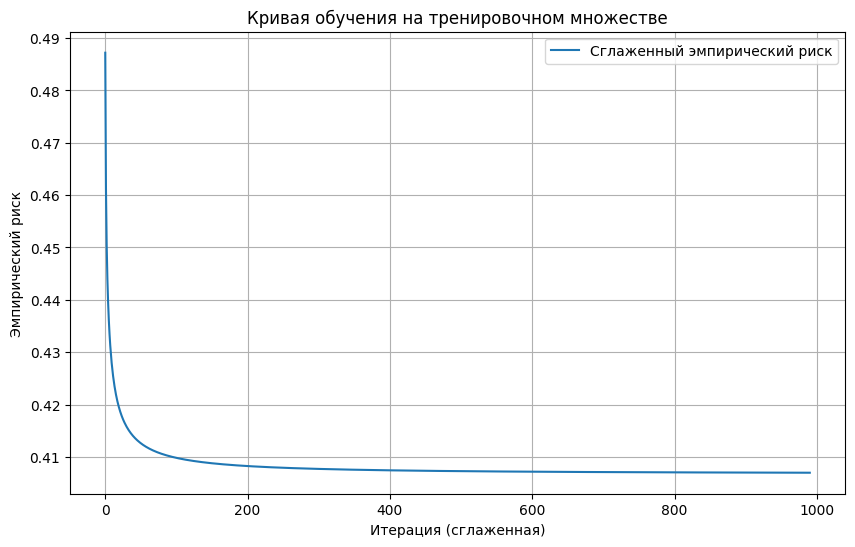

In [5]:
model = LinearClassifierGD(
    loss_type="logistic",
    learning_rate=0.55,
    alpha=0.0001,
    l1_ratio=0.05,
)
model.fit(X_train, y_train, X_test, y_test)

plt.figure(figsize=(10, 6))
plt.plot(
    np.convolve(model.train_loss_history, np.ones(10) / 10, mode="valid"),
    label="Сглаженный эмпирический риск",
)
plt.xlabel("Итерация (сглаженная)")
plt.ylabel("Эмпирический риск")
plt.title("Кривая обучения на тренировочном множестве")
plt.legend()
plt.grid(True)
plt.show()

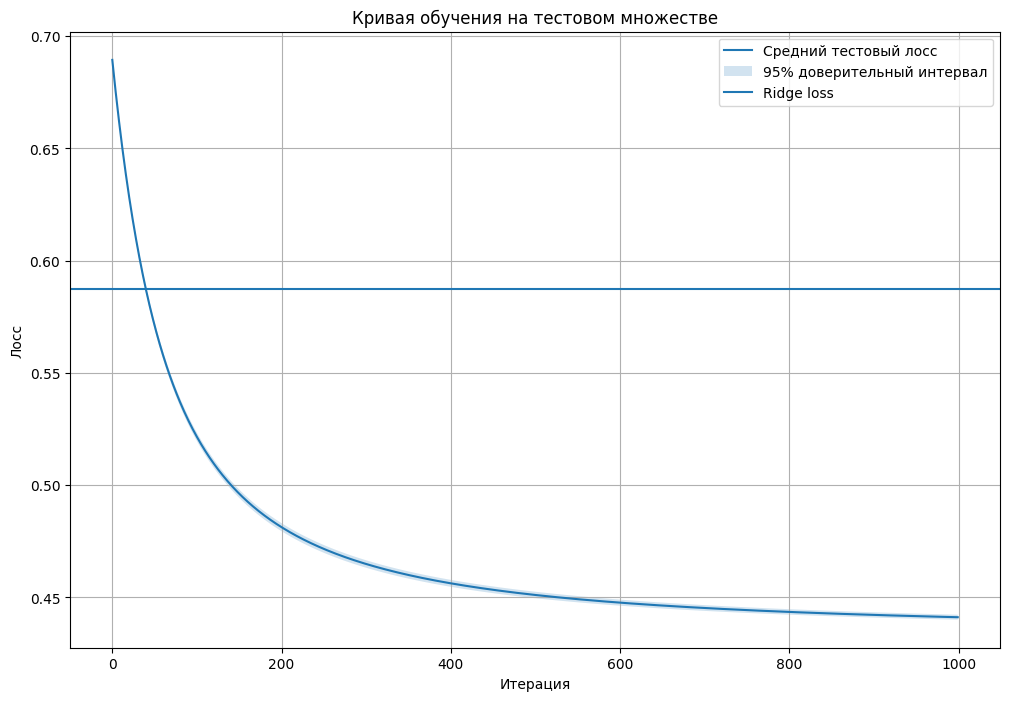

In [11]:
n_splits = 10
test_loss_histories = []
for i in range(n_splits):
    X_train, X_test, y_train, y_test = load_data()
    gd_model = LinearClassifierGD(loss_type="logistic", l1_ratio=0.1, alpha=0.01)
    gd_model.fit(X_train, y_train, X_test, y_test)
    test_loss_histories.append(gd_model.test_loss_history)
test_loss_histories = np.array(test_loss_histories)
mean_loss = np.mean(test_loss_histories, axis=0)
margin = 1.96 * np.std(test_loss_histories, axis=0) / np.sqrt(n_splits)

ridge_model = LinearRegressionRidge()
ridge_model.fit(X_train, y_train)
loss = np.mean(np.log(1 + np.exp(-y_test * ridge_model.predict(X_test))))

plt.figure(figsize=(12, 8))

plt.plot(mean_loss, label="Средний тестовый лосс")
plt.fill_between(
    range(len(mean_loss)),
    mean_loss - margin,
    mean_loss + margin,
    alpha=0.2,
    label="95% доверительный интервал",
)
plt.axhline(y=loss, label="Ridge loss")

plt.xlabel("Итерация")
plt.ylabel("Лосс")
plt.title("Кривая обучения на тестовом множестве")
plt.legend()
plt.grid(True)
plt.show()

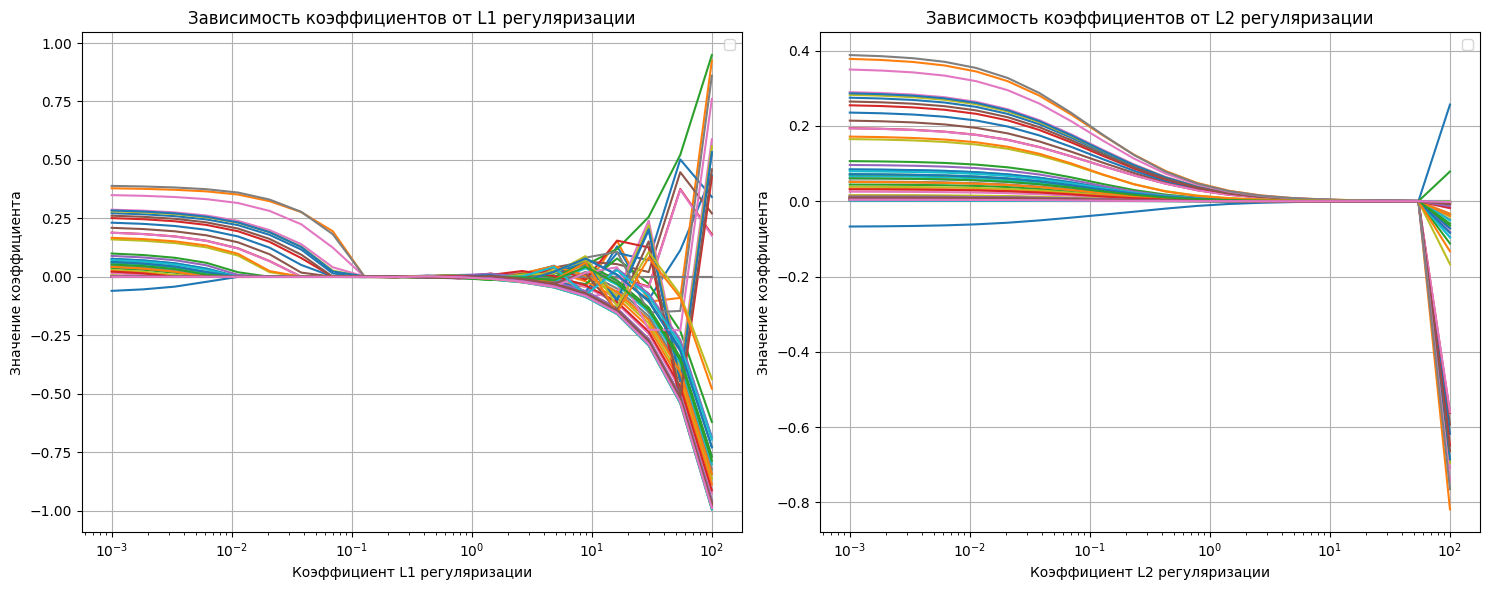

In [12]:
l1_alphas = np.logspace(-3, 2, 20)
l1_coefs = []
for alpha in l1_alphas:
    model = LinearClassifierGD(loss_type="logistic", l1_ratio=1.0, alpha=alpha)
    model.fit(X_train, y_train)
    l1_coefs.append(model.w)

l2_alphas = np.logspace(-3, 2, 20)
l2_coefs = []
for alpha in l2_alphas:
    model = LinearClassifierGD(loss_type="logistic", l1_ratio=0, alpha=alpha)
    model.fit(X_train, y_train)
    l2_coefs.append(model.w)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

l1_coefs = np.array(l1_coefs)
for i in range(l1_coefs.shape[1]):
    ax1.plot(l1_alphas, l1_coefs[:, i])

ax1.set_xscale("log")
ax1.set_xlabel("Коэффициент L1 регуляризации")
ax1.set_ylabel("Значение коэффициента")
ax1.set_title("Зависимость коэффициентов от L1 регуляризации")
ax1.legend()
ax1.grid(True)

l2_coefs = np.array(l2_coefs)
for i in range(l2_coefs.shape[1]):
    ax2.plot(l2_alphas, l2_coefs[:, i])

ax2.set_xscale("log")
ax2.set_xlabel("Коэффициент L2 регуляризации")
ax2.set_ylabel("Значение коэффициента")
ax2.set_title("Зависимость коэффициентов от L2 регуляризации")
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.show()